# Ability & Creature Explorer

Browse creature stats, ability assignments, and role/passive distributions from the local D1 database.

In [21]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SETTINGS                                              ║
# ╚══════════════════════════════════════════════════════════╝
NORMALIZE_BY_RARITY = True  # Scale all creatures to 170 total stats (removes rarity variance)

import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DB_DIR = Path.home() / 'Documents' / 'Repos' / 'paleo-waifu' / '.wrangler' / 'state' / 'v3' / 'd1' / 'miniflare-D1DatabaseObject'
DB_PATH = next((f for f in DB_DIR.iterdir() if f.suffix == '.sqlite'), None)

if DB_PATH is None:
    raise FileNotFoundError(f'No .sqlite file found in {DB_DIR}')

conn = sqlite3.connect(DB_PATH)

ROLE_ORDER = ['striker', 'tank', 'scout', 'support', 'bruiser', 'specialist']
ROLE_COLORS = {
    'striker': '#EF4444', 'tank': '#3B82F6', 'scout': '#22C55E',
    'support': '#EAB308', 'bruiser': '#A855F7', 'specialist': '#06B6D4',
}
RARITY_ORDER = ['common', 'uncommon', 'rare', 'epic', 'legendary']
STAT_COLS = ['hp', 'atk', 'def', 'spd', 'abl']
TARGET_TOTAL = 170

mode = 'NORMALIZED (170 total)' if NORMALIZE_BY_RARITY else 'RAW STATS'
print(f'Connected to {DB_PATH.name}')
print(f'Mode: {mode}')

Connected to b04c5095b45a86ddff42da8364d11c28ceec1c12315f9484c93c031441fd8c63.sqlite
Mode: NORMALIZED (170 total)


---
## 1. Load All Data

In [22]:
# Creatures with battle stats
creatures = pd.read_sql_query("""
    SELECT c.name, c.rarity, c.diet, c.type AS creature_type, c.era,
           cbs.role, cbs.hp, cbs.atk, cbs.def, cbs.spd, cbs.abl,
           cbs.creature_id
    FROM creature_battle_stats cbs
    JOIN creature c ON c.id = cbs.creature_id
    ORDER BY c.name
""", conn)
creatures['total'] = creatures[STAT_COLS].sum(axis=1)

# Normalize if enabled
if NORMALIZE_BY_RARITY:
    for stat in STAT_COLS:
        creatures[stat] = (creatures[stat] / creatures['total'] * TARGET_TOTAL).round(1)
    creatures['total'] = TARGET_TOTAL

# Ability assignments
abilities = pd.read_sql_query("""
    SELECT ca.creature_id, ca.slot, ca.display_name, ca.template_id,
           at.type AS ability_type, at.category, at.multiplier, at.cooldown, at.duration,
           at.stat_affected, at.effect_value
    FROM creature_ability ca
    JOIN ability_template at ON at.id = ca.template_id
    ORDER BY ca.creature_id, ca.slot
""", conn)

# Merge for easy lookup
merged = creatures.merge(abilities, on='creature_id', how='left')

print(f'Creatures: {len(creatures)}')
print(f'Ability assignments: {len(abilities)}')
print(f'Roles: {dict(creatures["role"].value_counts())}')
if NORMALIZE_BY_RARITY:
    print(f'All stats normalized to {TARGET_TOTAL} total')

Creatures: 415
Ability assignments: 1245
Roles: {'tank': np.int64(106), 'scout': np.int64(80), 'bruiser': np.int64(79), 'striker': np.int64(71), 'support': np.int64(57), 'specialist': np.int64(22)}
All stats normalized to 170 total


---
## 2. Role Distribution

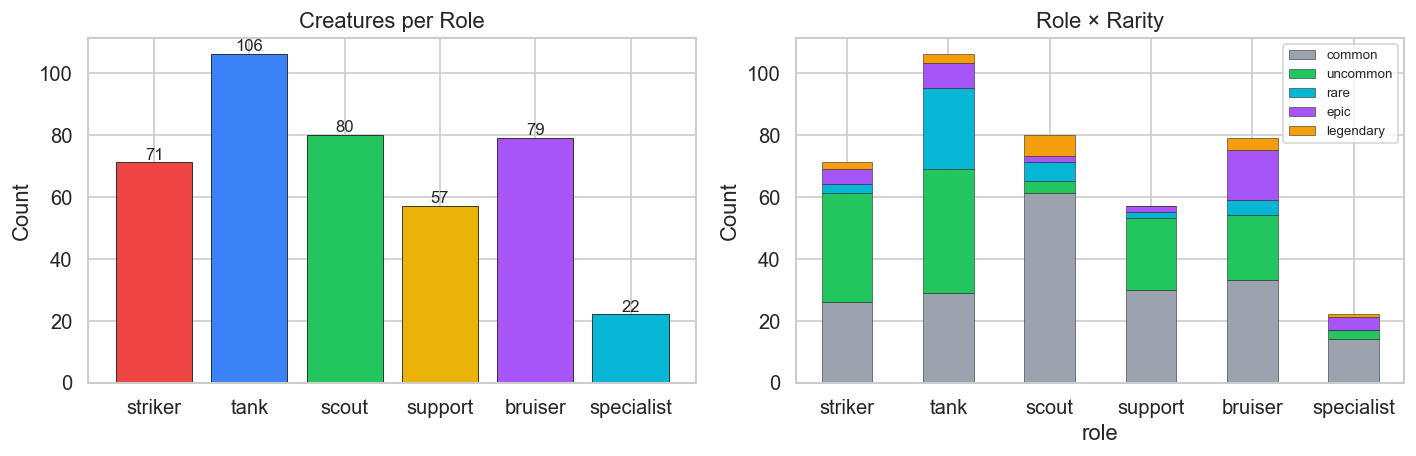

In [23]:
role_counts = creatures['role'].value_counts().reindex(ROLE_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [ROLE_COLORS[r] for r in ROLE_ORDER]
axes[0].bar(ROLE_ORDER, role_counts, color=colors, edgecolor='k', linewidth=0.5)
for i, v in enumerate(role_counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)
axes[0].set_ylabel('Count')
axes[0].set_title('Creatures per Role')

# By rarity within role
ct = pd.crosstab(creatures['role'], creatures['rarity'])
ct = ct.reindex(index=ROLE_ORDER, columns=RARITY_ORDER, fill_value=0)
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#9CA3AF', '#22C55E', '#06B6D4', '#A855F7', '#F59E0B'],
        edgecolor='k', linewidth=0.3)
axes[1].set_title('Role × Rarity')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 3. Stat Distributions by Role

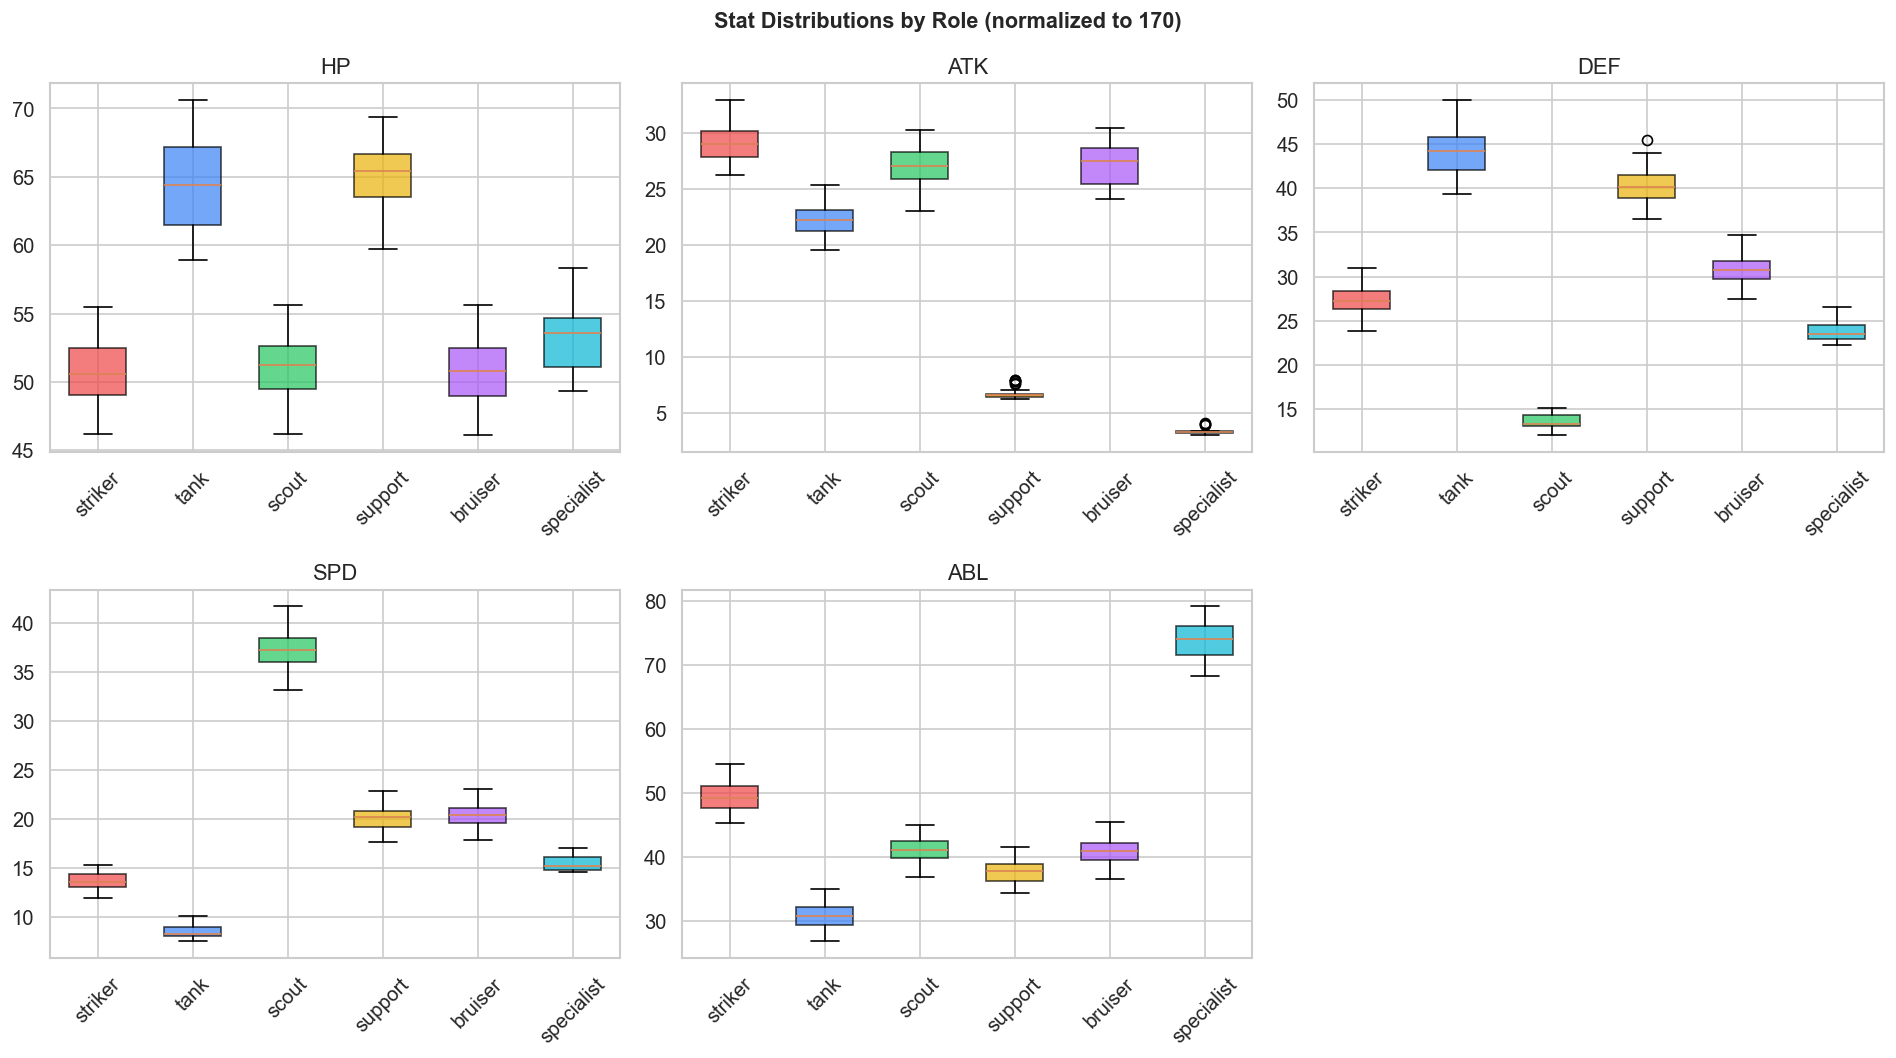

Average stats by role (normalized to 170):


,hp,atk,def,spd,abl,total
role,,,,,,
striker,50.6,29.1,27.2,13.6,49.4,170.0
tank,64.4,22.2,44.1,8.5,30.8,170.0
scout,51.1,27.1,13.6,37.3,41.0,170.0
support,65.1,6.7,40.3,20.2,37.6,170.0
bruiser,50.7,27.3,30.7,20.4,40.9,170.0
specialist,53.3,3.4,23.8,15.5,74.0,170.0


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, stat in enumerate(STAT_COLS):
    data = [creatures[creatures['role'] == r][stat] for r in ROLE_ORDER]
    bp = axes_flat[i].boxplot(data, tick_labels=ROLE_ORDER, patch_artist=True, widths=0.6)
    for patch, role in zip(bp['boxes'], ROLE_ORDER):
        patch.set_facecolor(ROLE_COLORS[role])
        patch.set_alpha(0.7)
    axes_flat[i].set_title(stat.upper())
    axes_flat[i].tick_params(axis='x', rotation=45)

# Hide the unused 6th subplot
axes_flat[5].set_visible(False)

suffix = ' (normalized to 170)' if NORMALIZE_BY_RARITY else ''
fig.suptitle(f'Stat Distributions by Role{suffix}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Average stats table
avg_stats = creatures.groupby('role')[STAT_COLS + ['total']].mean().reindex(ROLE_ORDER).round(1)
print(f'Average stats by role{suffix}:')
display(avg_stats)

---
## 4. Active Ability Distribution by Role

Which active abilities does each role use?

Active abilities assigned: 830
Unique active templates used: 36



role,striker,tank,scout,support,bruiser,specialist,total
template_id,,,,,,,
claw_strike,20,1,39,1,2,0,63
bite,23,0,15,0,7,0,45
ambush,9,0,32,0,1,0,42
shield_wall,0,41,0,0,0,0,41
adrenaline_rush,3,0,28,6,2,0,39
horn_charge,11,2,0,1,25,0,39
tail_sweep,1,28,0,2,8,0,39
stomp,1,26,0,1,9,0,37
provoke,0,37,0,0,0,0,37


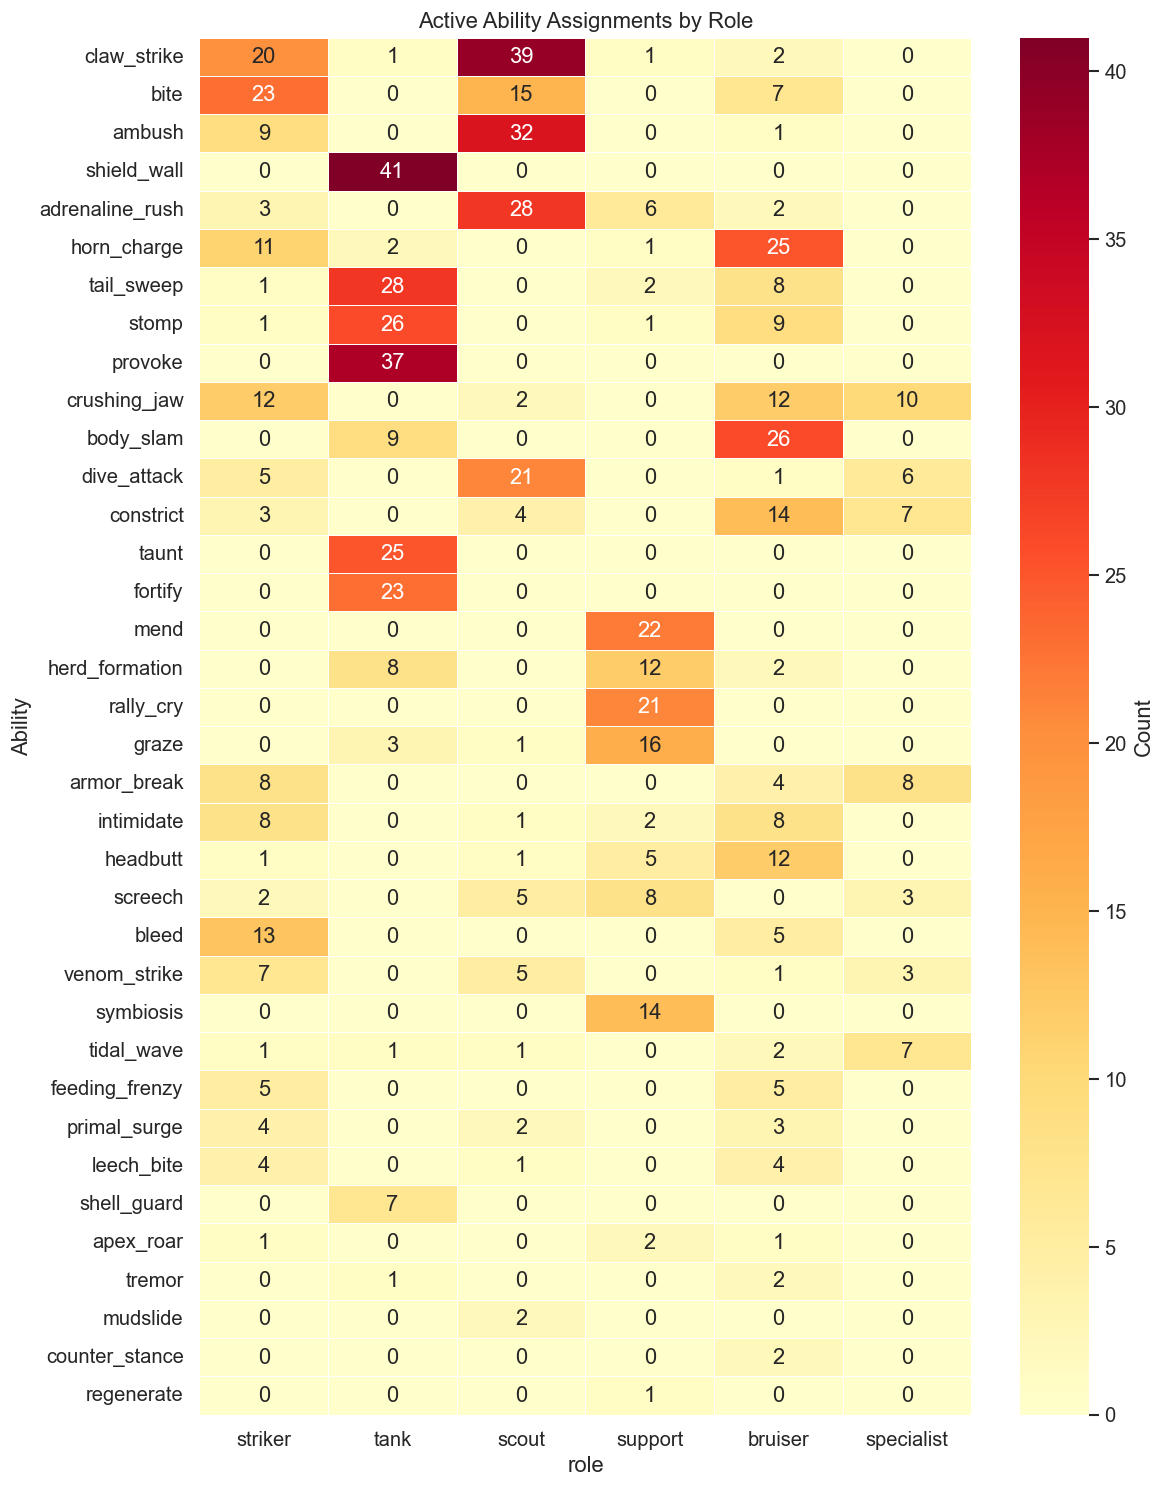

In [25]:
actives = merged[merged['ability_type'] == 'active'].copy()

# Crosstab: role × ability
ct = pd.crosstab(actives['template_id'], actives['role'])
ct = ct.reindex(columns=ROLE_ORDER, fill_value=0)
ct['total'] = ct.sum(axis=1)
ct = ct.sort_values('total', ascending=False)

print(f'Active abilities assigned: {len(actives)}')
print(f'Unique active templates used: {actives["template_id"].nunique()}')
print()
display(ct)

# Heatmap
fig, ax = plt.subplots(figsize=(10, max(5, len(ct) * 0.35)))
sns.heatmap(ct.drop(columns='total'), annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_title('Active Ability Assignments by Role')
ax.set_ylabel('Ability')
plt.tight_layout()
plt.show()

---
## 5. Passive Ability Distribution by Role

In [ ]:
passives = merged[merged['ability_type'] == 'passive'].copy()

ct = pd.crosstab(passives['template_id'], passives['role'])
ct = ct.reindex(columns=ROLE_ORDER, fill_value=0)
ct['total'] = ct.sum(axis=1)
ct = ct.sort_values('total', ascending=False)

print(f'Unique passive templates used: {passives["template_id"].nunique()}')
print()
display(ct)

fig, ax = plt.subplots(figsize=(10, max(4, len(ct) * 0.4)))
sns.heatmap(ct.drop(columns='total'), annot=True, fmt='d', cmap='BuPu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_title('Passive Ability Assignments by Role')
ax.set_ylabel('Passive')
plt.tight_layout()
plt.show()

---
## 6. Ability Templates Reference

All ability templates with their stats.

In [ ]:
templates = pd.read_sql_query("""
    SELECT id, name, type, category, target, multiplier, cooldown,
           duration, stat_affected, effect_value, description
    FROM ability_template
    ORDER BY type, category, id
""", conn)

# Count how many creatures use each
usage = abilities['template_id'].value_counts().rename('creatures_using')
templates = templates.merge(usage, left_on='id', right_index=True, how='left')
templates['creatures_using'] = templates['creatures_using'].fillna(0).astype(int)

print('ACTIVE ABILITIES')
display(templates[templates['type'] == 'active'][[
    'id', 'name', 'category', 'target', 'multiplier', 'cooldown',
    'duration', 'stat_affected', 'effect_value', 'creatures_using'
]])

print('\nPASSIVE ABILITIES')
display(templates[templates['type'] == 'passive'][[
    'id', 'name', 'stat_affected', 'effect_value', 'duration', 'creatures_using', 'description'
]])

---
## 7. Creature Lookup

Search for specific creatures by name, role, rarity, or ability.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  SEARCH — edit the filter and re-run                   ║
# ╚══════════════════════════════════════════════════════════╝

# Filter options (set to None to skip):
SEARCH_NAME = None          # e.g. 'Irritator', partial match
SEARCH_ROLE = None          # e.g. 'striker'
SEARCH_RARITY = None        # e.g. 'legendary'
SEARCH_ABILITY = None       # e.g. 'dive_attack', matches template_id
SEARCH_PASSIVE = None       # e.g. 'apex_predator', matches template_id

df = creatures.copy()

if SEARCH_NAME:
    df = df[df['name'].str.contains(SEARCH_NAME, case=False)]
if SEARCH_ROLE:
    df = df[df['role'] == SEARCH_ROLE]
if SEARCH_RARITY:
    df = df[df['rarity'] == SEARCH_RARITY]
if SEARCH_ABILITY:
    ids_with_ability = abilities[abilities['template_id'] == SEARCH_ABILITY]['creature_id'].unique()
    df = df[df['creature_id'].isin(ids_with_ability)]
if SEARCH_PASSIVE:
    ids_with_passive = abilities[(abilities['template_id'] == SEARCH_PASSIVE) & (abilities['slot'] == 'passive')]['creature_id'].unique()
    df = df[df['creature_id'].isin(ids_with_passive)]

print(f'Found {len(df)} creatures')

if len(df) > 0 and len(df) <= 50:
    # Show with abilities
    for _, c in df.iterrows():
        ca = abilities[abilities['creature_id'] == c['creature_id']]
        active1 = ca[ca['slot'] == 'active1']
        active2 = ca[ca['slot'] == 'active2']
        passive = ca[ca['slot'] == 'passive']
        
        a1 = active1.iloc[0]['display_name'] if len(active1) else '—'
        a2 = active2.iloc[0]['display_name'] if len(active2) else '—'
        p = passive.iloc[0]['display_name'] if len(passive) else '—'
        
        print(f"\n{c['name']} — {c['rarity']} {c['role']} ({c['creature_type']}, {c['diet']})")
        print(f"  HP:{c['hp']}  ATK:{c['atk']}  DEF:{c['def']}  SPD:{c['spd']}  ABL:{c['abl']}  (total:{c['total']})")
        print(f"  Active 1: {a1}  |  Active 2: {a2}  |  Passive: {p}")
elif len(df) > 50:
    display(df[['name', 'rarity', 'role', 'creature_type', 'diet', 'hp', 'atk', 'def', 'spd', 'abl', 'total']])

---
## 8. Ability Combos

Most common active1 + active2 + passive combinations.

In [ ]:
# Pivot abilities to one row per creature
pivoted = abilities.pivot_table(
    index='creature_id', columns='slot', values='template_id', aggfunc='first'
).reset_index()

pivoted = pivoted.merge(creatures[['creature_id', 'name', 'role', 'rarity']], on='creature_id')

if 'active1' in pivoted.columns and 'active2' in pivoted.columns and 'passive' in pivoted.columns:
    combos = pivoted.groupby(['active1', 'active2', 'passive']).agg(
        count=('creature_id', 'size'),
        roles=('role', lambda x: ', '.join(sorted(x.unique()))),
        creatures=('name', lambda x: ', '.join(sorted(x)[:3]) + ('...' if len(x) > 3 else ''))
    ).sort_values('count', ascending=False).reset_index()
    
    print(f'Unique ability combos: {len(combos)}')
    print(f'\nTop 20 most common combos:')
    display(combos.head(20))
else:
    print('Missing ability slots in data')

In [ ]:
conn.close()
print('Done.')